In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score

In [3]:
df = pd.read_csv("C:\Datasets\IDS_Dataset\Portscan-Friday-no-metadata.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Mohammad Saquib\AppData\Local\Temp\ipykernel_10488\1461168097.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\Datasets\IDS_Dataset\Portscan-Friday-no-metadata.csv")


In [4]:
df.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,1266342,41,44,2664,6954,456,0,64.97561,109.864570,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1319353,41,44,2664,6954,456,0,64.97561,109.864570,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,160,1,1,0,0,0,0,0.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1303488,41,42,2728,6634,456,0,66.53658,110.129944,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,77,1,2,0,0,0,0,0.00000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [5]:
df.shape

(119522, 78)

In [6]:
df["Label"].value_counts()

Label
Benign      117566
PortScan      1956
Name: count, dtype: int64

In [7]:
df = df.drop(columns=[
    "Fwd Packets Length Total", "Bwd Packets Length Total",
    "Fwd Packet Length Max", "Bwd Packet Length Max",
    "Fwd Packet Length Min", "Bwd Packet Length Min",
    "Fwd Packet Length Std", "Bwd Packet Length Std",
    "Flow IAT Std", "Flow IAT Total",
    "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min",
    "Bwd IAT Total", "Bwd IAT Std", "Bwd IAT Max", "Bwd IAT Min",
    "Fwd PSH Flags", "Bwd PSH Flags",
    "Fwd URG Flags", "Bwd URG Flags",
    "Packet Length Variance",
    "PSH Flag Count", "URG Flag Count", "CWE Flag Count", "ECE Flag Count",
    "Down/Up Ratio", "Avg Packet Size",
    "Avg Fwd Segment Size", "Avg Bwd Segment Size",
    "Fwd Avg Bytes/Bulk", "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk", "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate",
    "Subflow Bwd Bytes",
    "Init Fwd Win Bytes", "Init Bwd Win Bytes",
    "Fwd Act Data Packets", "Fwd Seg Size Min",
    "Active Mean", "Active Std", "Active Max", "Active Min",
    "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
], axis=1, errors='ignore')

In [8]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [9]:
label_mapping = {'Benign': 0, 'PortScan': 1}
y = y.map(label_mapping)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import torch

# 1. SMOTE on training data
sm = SMOTE(sampling_strategy=0.2, random_state=42)
X_res_np, y_res_np = sm.fit_resample(X_train, y_train)

# 2. Scaling - CRITICAL: Fit on training, transform both
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res_np)
X_test_scaled = scaler.transform(X_test)

# 3. Create Final Tensors
X_tensor = torch.tensor(X_res_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_res_np.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print(f"Data ready. Train shape: {X_tensor.shape}, Test shape: {X_test_tensor.shape}")

Data ready. Train shape: torch.Size([112844, 29]), Test shape: torch.Size([23905, 29])


In [12]:
import torch.nn as nn

class PortScanDetector(nn.Module):
    def __init__(self, input_dim):
        super(PortScanDetector, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 2) 
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2) 

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        return self.output(x)

# Initialize the model using the number of features in X_tensor
global_brain = PortScanDetector(X_tensor.shape[1])
print("Global model 'global_brain' initialized.")

Global model 'global_brain' initialized.


In [13]:
import torch.nn as nn
import torch.optim as optim

weights = torch.tensor([1.0, 15.0]) 
criterion = nn.CrossEntropyLoss(weight=weights)

def local_train(model, train_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y) 
            loss.backward()
            optimizer.step()

In [14]:
from sklearn.metrics import classification_report

def evaluate_with_threshold(model, X_test, y_true, threshold=0.8):
    model.eval() # Now correctly called on the model
    with torch.no_grad():
        outputs = model(X_test)
        probs = torch.softmax(outputs, dim=1)[:, 1] 
        predictions = (probs > threshold).long()
    
    # Print the report directly
    print(f"--- Global Model Performance (Threshold: {threshold}) ---")
    print(classification_report(y_true, predictions, target_names=['Benign', 'PortScan']))
    return predictions

# Call it with the model, test features, and true labels
preds = evaluate_with_threshold(global_brain, X_test_tensor, y_test_tensor, threshold=0.8)

--- Global Model Performance (Threshold: 0.8) ---
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99     23529
    PortScan       0.00      0.00      0.00       376

    accuracy                           0.98     23905
   macro avg       0.49      0.50      0.50     23905
weighted avg       0.97      0.98      0.98     23905



C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a separate hold-out test set (X_test, y_test)
# Convert them to tensors if you haven't already
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [16]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import copy

def create_client_loaders(X, y, num_clients=3, batch_size=32):
    dataset = TensorDataset(X, y)
    split_size = len(dataset) // num_clients
    lengths = [split_size] * (num_clients - 1)
    lengths.append(len(dataset) - sum(lengths))
    client_data = random_split(dataset, lengths)
    return [DataLoader(ds, batch_size=batch_size, shuffle=True) for ds in client_data]

# Use the SCALED X_tensor
client_loaders = create_client_loaders(X_tensor, y_tensor, num_clients=3)

def federated_averaging(global_model, client_loaders, rounds=10, local_epochs=5):
    # Weight of 10.0 for PortScan helps balance precision and recall
    weights = torch.tensor([1.0, 100.0]) 
    criterion = nn.CrossEntropyLoss(weight=weights)

    for r in range(rounds):
        local_weights = []
        for i, loader in enumerate(client_loaders):
            local_model = copy.deepcopy(global_model)
            optimizer = torch.optim.Adam(local_model.parameters(), lr=0.0001)
            
            local_model.train()
            for epoch in range(local_epochs):
                for batch_X, batch_y in loader:
                    optimizer.zero_grad()
                    outputs = local_model(batch_X)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()
            local_weights.append(local_model.state_dict())
        
        # Aggregation
        global_dict = global_model.state_dict()
        for key in global_dict.keys():
            global_dict[key] = torch.stack([local_weights[j][key] for j in range(len(local_weights))], 0).mean(0)
        global_model.load_state_dict(global_dict)
        print(f"Round {r+1} complete.")
        
    return global_model

# Start Training
global_brain = federated_averaging(global_brain, client_loaders, rounds=10, local_epochs=10)

Round 1 complete.
Round 2 complete.
Round 3 complete.
Round 4 complete.
Round 5 complete.
Round 6 complete.
Round 7 complete.
Round 8 complete.
Round 9 complete.
Round 10 complete.


In [17]:
def evaluate_global_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predictions = torch.max(outputs, 1)
        
    # Generate the report
    print("--- Global Model Performance ---")
    print(classification_report(y_test, predictions, target_names=['Benign', 'PortScan']))
    
    return predictions

# Run evaluation
preds = evaluate_global_model(global_brain, X_test_tensor, y_test_tensor)

--- Global Model Performance ---
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99     23529
    PortScan       0.00      0.00      0.00       376

    accuracy                           0.98     23905
   macro avg       0.49      0.50      0.50     23905
weighted avg       0.97      0.98      0.98     23905



C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

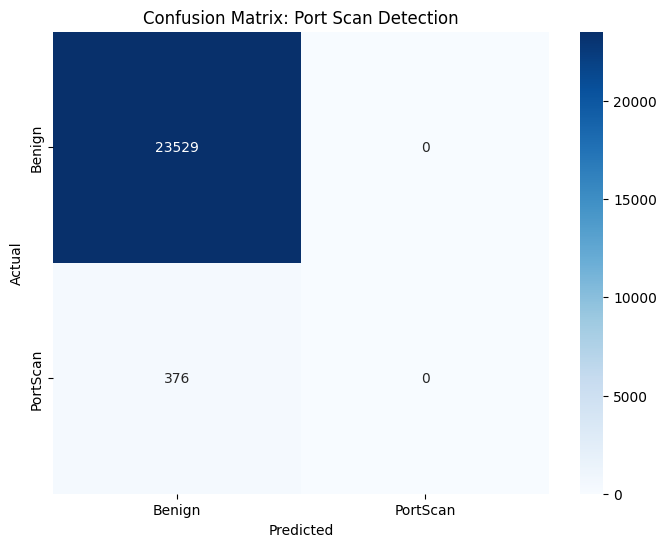

In [18]:
def plot_results(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'PortScan'], 
                yticklabels=['Benign', 'PortScan'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Port Scan Detection')
    plt.show()

plot_results(y_test_tensor.numpy(), preds.numpy())

In [19]:
from sklearn.metrics import classification_report

def evaluate_with_threshold(model, X_test, y_true, threshold=0.9):
    model.eval() 
    with torch.no_grad():
        outputs = model(X_test)
        probs = torch.softmax(outputs, dim=1)[:, 1] 
        # Higher threshold (0.9) ensures we only flag clear Port Scans, raising Precision
        predictions = (probs > threshold).long()
        
    print(f"--- Global Performance (Threshold: {threshold}) ---")
    print(classification_report(y_true, predictions, target_names=['Benign', 'PortScan']))
    return predictions

# Run Evaluation on the scaled test tensor
preds = evaluate_with_threshold(global_brain, X_test_tensor, y_test_tensor, threshold=0.3)

--- Global Performance (Threshold: 0.3) ---
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99     23529
    PortScan       0.00      0.00      0.00       376

    accuracy                           0.98     23905
   macro avg       0.49      0.50      0.50     23905
weighted avg       0.97      0.98      0.98     23905



C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [20]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Benign', 'PortScan'], 
                yticklabels=['Benign', 'PortScan'])
    plt.title('Global Model: Port Scan Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [21]:
# Add this to your main loop to track progress
history = {'loss': []}

# Inside your communication round loop:
# round_loss = sum(local_losses) / len(local_losses)
# history['loss'].append(round_loss)

def plot_learning_curve(loss_history):
    plt.plot(loss_history)
    plt.title('Federated Learning Convergence')
    plt.xlabel('Communication Rounds')
    plt.ylabel('Global Loss')
    plt.grid(True)
    plt.show()

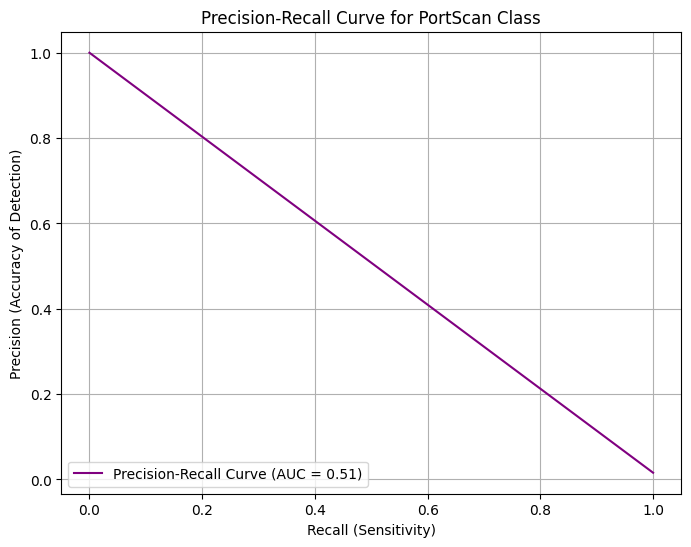

In [22]:
from sklearn.metrics import precision_recall_curve, auc

# Get probability scores instead of just hard 0/1 predictions
global_brain.eval()
with torch.no_grad():
    # We take the probabilities for the positive class (PortScan)
    probs = torch.softmax(global_brain(X_test_tensor), dim=1)[:, 1].numpy()

precision, recall, _ = precision_recall_curve(y_test_tensor.numpy(), probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})', color='purple')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Accuracy of Detection)')
plt.title('Precision-Recall Curve for PortScan Class')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()